In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from da_models.lorenz63 import rhs

In [2]:
ic = np.load("../data/lorenz63_ic.npy")
print(ic)

[ 2.49960256  2.55741113 19.74661021]


**Simulation**

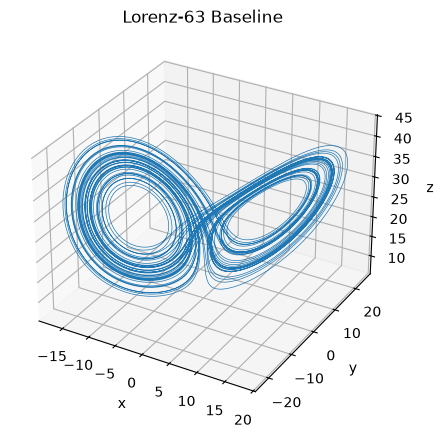

In [3]:
t_span = (0, 50)
t_eval = np.linspace(*t_span, 10000)

sol = solve_ivp(rhs, t_span, ic, t_eval=t_eval, args=(10.0, 28.0, 8/3), rtol=1e-9, atol=1e-9)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Lorenz-63 Baseline')
plt.show()

**Perturbation**

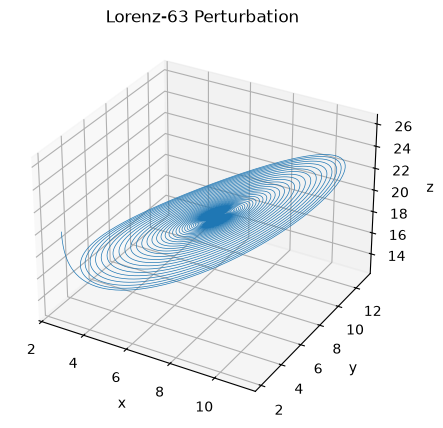

In [4]:
rho_new = 21.0

sol_tweak = solve_ivp(rhs, t_span, ic, t_eval=t_eval, args=(10.0, rho_new, 8/3), rtol=1e-9, atol=1e-9)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(sol_tweak.y[0], sol_tweak.y[1], sol_tweak.y[2], lw=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title(f'Lorenz-63 Perturbation')
plt.show()

**Additive Noise**

In [5]:
from da_models.integrators import euler_maruyama

In [6]:
dt = 0.01
q = 3.5
seed = 0

t_noisy, X_noisy = euler_maruyama(
    rhs, ic, t_span, dt=dt, q=q, seed=seed,
    rhs_kwargs={'sigma': 10.0, 'rho': 28.0, 'beta': 8/3}
)

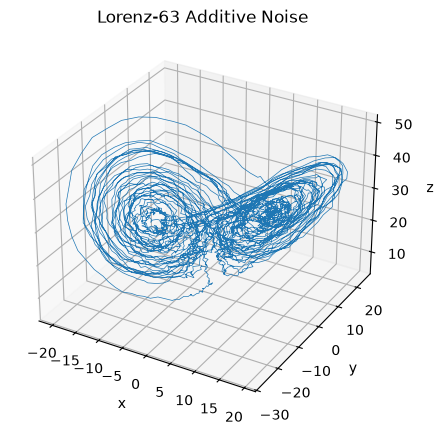

In [7]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot(X_noisy[:, 0], X_noisy[:, 1], X_noisy[:, 2], lw=0.5)
ax.set_title(f'Lorenz-63 Additive Noise')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

plt.show()

**Observations**

Increasing $\rho$ causes the attractor to disappear and an inward spiral to appear. In contrast, a little bit of noise keeps the attractor mostly intact.